This noteobok demonstrates the CFD calcuations for cooling of a circular find by means of convective heat transfer along its length.  

The base is at temperature ($T_B$)
The ambient temperature the fin is exposed to is $T_{inf}$

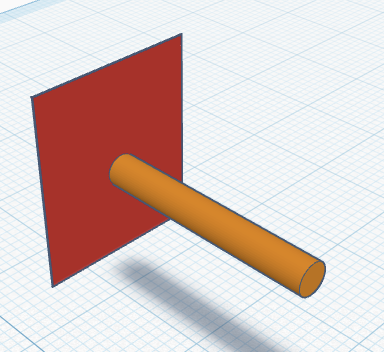

The governing equation for the convective heat transfer is as below.

$$ \frac{d}{dx}\left( k \frac{dT}{dx} \right)  + S = 0 $$
where $$S =  - \frac{hP(T - T_{\infty})}{A} $$


 => $$
\frac{d}{dx}\left( k A \frac{dT}{dx} \right) - h P \left( T - T_{\infty} \right) = 0
$$

Integrating over control volume

=> $$ ∫_{cv} \frac{d}{dx}\left( k A \frac{dT}{dx} \right) dV - ∫_{cv}hP(T - T_{∞}) dV = 0 $$


=> $$ ∫_{cv} \frac{d}{dx}\left( \frac{dT}{dx} \right) dV - ∫_{cv}n^2(T - T_{∞}) dV = 0 $$ where $$n^2 = \frac{hP}{kA}$$

=> $$ \left(A\frac{dT}{dx} \right)_e - \left(A\frac{dT}{dx} \right)_w = n^2(T - T_{∞}) A \delta x $$

=> $$ \left(\frac{dT}{dx} \right)_e - \left(\frac{dT}{dx} \right)_w = n^2(T - T_{∞}) \delta x $$

In [11]:
# Define parameters
L = 1.0  # m (Length of the fin)
num_nodes = 5  # Number of nodes
n_squared = 25  # hp/ka
Tb = 100  # Celsius (Temperature at the base)
T_inf = 20  # Celsius (Ambient temperature)

# Calculate delta_x
delta_x = L / (num_nodes)

print(f"Delta x: {delta_x} m")

Delta x: 0.2 m


### Setting up the system of linear equations [A] * [T] = [B]
We have 5 unknown temperatures ($T_1, T_2, T_3, T_4, T_5$), so we need 5 equations.

**Equation 1 (Node 1 - at $\delta x / 2$ from base):**
Using the general control volume equation $$\left(\frac{dT}{dx} \right)_e - \left(\frac{dT}{dx} \right)_w = n^2(T_P - T_{\infty}) \delta x $$. For Node 1, the West face is at $T_b$ (at $x=0$). The East face is at $T_2$ (at $x=\delta x$).
$$ \frac{T_2 - T_1}{\delta x} - \frac{T_1 - T_b}{\delta x/2} = n^2(T_1 - T_{\infty}) \delta x $$
Multiplying by $\delta x$ and rearranging, we get:
$$ (3 + n^2 \delta x^2) T_1 - T_2 = 2T_b + n^2 T_{\infty} \delta x^2 $$

**Internal Nodes (Node 2, 3, 4):**
For a general internal node $T_i$, its neighbors are $T_{i-1}$ (West) and $T_{i+1}$ (East).
$$ \frac{T_{i+1}-T_i}{\delta x} - \left(\frac{T_i - T_{i-1}}{\delta x}\right) = n^2 (T_i - T_{\infty}) \delta x $$
Multiplying by $\delta x$ and rearranging, we get:
$$ -T_{i-1} + (2 + n^2 \delta x^2) T_i - T_{i+1} = n^2 T_{\infty} \delta x^2 $$

**Equation 5 (Node 5 - Tip, insulated):**
For Node 5, the West face is at $T_4$. The East face is at $x=L$, where $$\frac{dT}{dx} = 0$$ due to insulation.
$$ 0 - \left(\frac{T_5 - T_4}{\delta x}\right) = n^2(T_5 - T_{\infty}) \delta x $$
Multiplying by $\delta x$ and rearranging, we get:
$$ T_4 - (1 + n^2 \delta x^2) T_5 = - n^2 T_{\infty} \delta x^2 $$

In [14]:
import numpy as np

# Initialize coefficient matrix A and constant vector B
A = np.zeros((num_nodes, num_nodes))
B = np.zeros(num_nodes)

# Common term for internal nodes
beta_squared_dx_squared = n_squared * delta_x**2

# Equation 1 (Node 1 - at delta_x/2 from base)
# (3 + n^2 * delta_x^2) * T_1 - T_2 = 2*Tb + n^2 * T_inf * delta_x^2
A[0, 0] = (3 + beta_squared_dx_squared)
A[0, 1] = -1
B[0] = 2 * Tb + beta_squared_dx_squared * T_inf

# Equations for internal nodes (Node 2, 3, 4)
# -T_{i-1} + (2 + n^2 * delta_x^2) * T_i - T_{i+1} = n^2 * T_inf * delta_x^2
for i in range(1, num_nodes - 1):
    # For node T_{i+1} (which is T_2, T_3, T_4 corresponding to i=1, 2, 3)
    # The coefficient for T_{i-1} (left neighbor) is -1
    A[i, i-1] = -1
    # The coefficient for T_i (current node) is (2 + beta_squared_dx_squared)
    A[i, i] = (2 + beta_squared_dx_squared)
    # The coefficient for T_{i+1} (right neighbor) is -1
    A[i, i+1] = -1
    # The constant term is n^2 * T_inf * delta_x^2
    B[i] = beta_squared_dx_squared * T_inf

# Equation 5 (Node 5 - Tip, insulated)
# T_4 - (1 + n^2 * delta_x^2) * T_5 = - n^2 * T_inf * delta_x^2
A[num_nodes-1, num_nodes-2] = 1  # Coefficient for T_4
A[num_nodes-1, num_nodes-1] = -(1 + beta_squared_dx_squared)  # Coefficient for T_5
B[num_nodes-1] = -beta_squared_dx_squared * T_inf

# Print the matrix A and vector B
print("Coefficient Matrix A:")
print(A)
print("\nConstant Vector B:")
print(B)


Coefficient Matrix A:
[[ 4. -1.  0.  0.  0.]
 [-1.  3. -1.  0.  0.]
 [ 0. -1.  3. -1.  0.]
 [ 0.  0. -1.  3. -1.]
 [ 0.  0.  0.  1. -2.]]

Constant Vector B:
[220.  20.  20.  20. -20.]


In [15]:
# Solve the system of equations
T = np.linalg.solve(A, B)

print("\nTemperatures at each node (in Celsius):")
for i, temp in enumerate(T):
    print(f"T_{i+1}: {temp:.2f} C")


Temperatures at each node (in Celsius):
T_1: 64.23 C
T_2: 36.91 C
T_3: 26.50 C
T_4: 22.60 C
T_5: 21.30 C


In [ ]:
# analytics


--- Comparison of Numerical and Analytical Solutions ---
Node | x-position (m) | Numerical Temp (C) | Analytical Temp (C) | Absolute Difference (C)
--------------------------------------------------------------------------------------
1    | 0.100           | 64.23              | 68.53               | 4.30
2    | 0.300           | 36.91              | 37.87               | 0.96
3    | 0.500           | 26.50              | 26.61               | 0.11
4    | 0.700           | 22.60              | 22.54               | 0.07
5    | 0.900           | 21.30              | 21.22               | 0.09


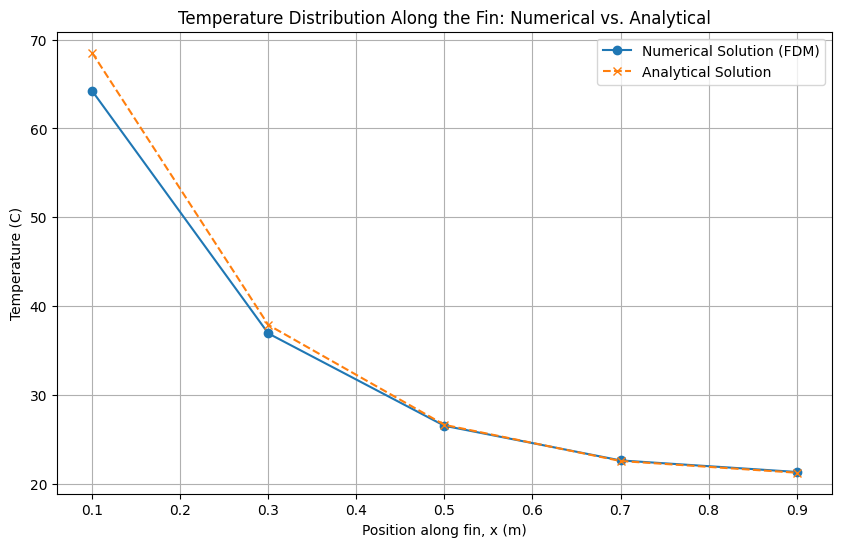

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Define the analytical solution function
def analytical_solution(x_val, L_val, n_val, Tb_val, T_inf_val):
    return T_inf_val + (Tb_val - T_inf_val) * (np.cosh(n_val * (L_val - x_val)) / np.cosh(n_val * L_val))

# Calculate n from n_squared
n = np.sqrt(n_squared)

# Calculate x positions for each node
x_nodes = np.linspace(delta_x / 2, L - delta_x / 2, num_nodes)

# Calculate analytical temperatures
T_analytical = np.array([analytical_solution(x, L, n, Tb, T_inf) for x in x_nodes])

print("\n--- Comparison of Numerical and Analytical Solutions ---")
print("Node | x-position (m) | Numerical Temp (C) | Analytical Temp (C) | Absolute Difference (C)")
print("--------------------------------------------------------------------------------------")
for i in range(num_nodes):
    diff = abs(T[i] - T_analytical[i])
    print(f"{i+1:<4} | {x_nodes[i]:<15.3f} | {T[i]:<18.2f} | {T_analytical[i]:<19.2f} | {diff:.2f}")

# Plotting the comparison
plt.figure(figsize=(10, 6))
plt.plot(x_nodes, T, 'o-', label='Numerical Solution (FDM)')
plt.plot(x_nodes, T_analytical, 'x--', label='Analytical Solution')
plt.title('Temperature Distribution Along the Fin: Numerical vs. Analytical')
plt.xlabel('Position along fin, x (m)')
plt.ylabel('Temperature (C)')
plt.legend()
plt.grid(True)
plt.show()